Final Project - Machine Learning by ADVANZ MOLEH
- Arya Bintang Fauzildan (24031554127)
- Ivan Andika Setyawan (24031554085)
- E.Adi Sforza Syahrul Ramadhan (24031554113)

# Import Session

In [1]:
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator

import numpy as np
import os
from pathlib import Path

from PIL import Image

from sklearn.model_selection import train_test_split

from tqdm import tqdm

import matplotlib.pyplot as plt
import seaborn as sns

# Inisiasi Param dan Path

## Target dan Output Path

Inisiasi Base gambar. Pembuatan direktori output

In [2]:
BASE_DIR = Path("gambarsampah/standardized_256")
OUTPUT_DIR = Path("features")
OUTPUT_DIR.mkdir(exist_ok=True)

Inisiasi besar gambar dan ukuran batch

In [3]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

Inisiasi Split

In [4]:
TEST_SIZE = 0.2
RANDOM_STATE = 42

Konfirmasi File

In [5]:
assert BASE_DIR.exists(), f"folder dataset tidak ada {BASE_DIR}"

CLASS_NAME = sorted([d.name for d in BASE_DIR.iterdir() if d.is_dir()])
NUM_CLASS = len(CLASS_NAME)

print(f"Dataset di {BASE_DIR}")
print(f"Ttoal Kelas {NUM_CLASS}")
print(f"Kelas {CLASS_NAME}")

Dataset di gambarsampah\standardized_256
Ttoal Kelas 10
Kelas ['battery', 'biological', 'cardboard', 'clothes', 'glass', 'metal', 'paper', 'plastic', 'shoes', 'trash']


# Informasi Dataset dan Distribusi Kelas

## Hitung jumlah gambar per kelas

In [6]:
class_counts = {}
for class_name in CLASS_NAME:
    class_path = BASE_DIR / class_name
    images = list(class_path.glob("*.jpg")) + \
             list(class_path.glob("*.jpeg")) + \
             list(class_path.glob("*.png"))
    class_counts[class_name] = len(images)

total_images = sum(class_counts.values())
avg_count    = total_images / NUM_CLASS

Distribusi Dataset

In [7]:
print(f"{'='*45}")
print(f"Distribusi Dataset ({total_images} total gambar)")
print(f"{'='*45}")
print(f"{'Kelas':<15} {'Jumlah':>8} {'Persentase':>12}")
print(f"{'-'*45}")
for class_name, count in sorted(class_counts.items(), key=lambda x: x[1]):
    pct = (count / total_images) * 100
    print(f"{class_name:<15} {count:>8} {pct:>11.1f}%")
print(f"{'-'*45}")
print(f"{'Total':<15} {total_images:>8} {'100.0%':>12}")
print(f"{'Rata-rata':<15} {avg_count:>8.0f}")

Distribusi Dataset (12259 total gambar)
Kelas             Jumlah   Persentase
---------------------------------------------
trash                453         3.7%
biological           699         5.7%
battery              756         6.2%
metal                930         7.6%
paper               1336        10.9%
cardboard           1411        11.5%
shoes               1449        11.8%
plastic             1597        13.0%
glass               1736        14.2%
clothes             1892        15.4%
---------------------------------------------
Total              12259       100.0%
Rata-rata           1226


Marking kelas minoritas

In [8]:
minority_classes = {k: v for k, v in class_counts.items() if v < avg_count}
print(f"Kelas minoritas (di bawah rata-rata gambar):")
for class_name, count in sorted(minority_classes.items(), key=lambda x: x[1]):
    print(f"   - {class_name} ({count} gambar)")

Kelas minoritas (di bawah rata-rata gambar):
   - trash (453 gambar)
   - biological (699 gambar)
   - battery (756 gambar)
   - metal (930 gambar)


Visualisasi distribusi data

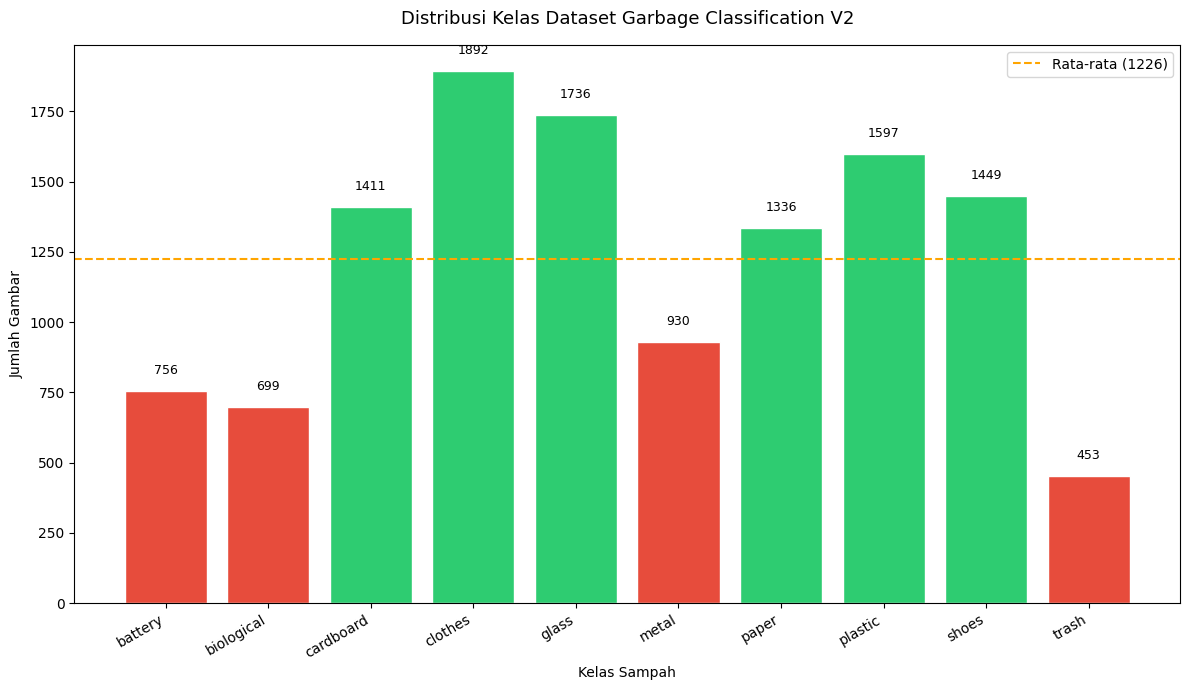

In [9]:
fig, ax = plt.subplots(figsize=(12, 7))

colors = ["#e74c3c" if v < avg_count else "#2ecc71" 
          for v in class_counts.values()]

bars = ax.bar(class_counts.keys(), class_counts.values(), color=colors, edgecolor="white")
ax.axhline(y=avg_count, color="orange", linestyle="--", linewidth=1.5, label=f"Rata-rata ({avg_count:.0f})")

# Label angka di atas bar
for bar, count in zip(bars, class_counts.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            str(count), ha="center", va="bottom", fontsize=9)

ax.set_title("Distribusi Kelas Dataset Garbage Classification V2", fontsize=13, pad=15)
ax.set_xlabel("Kelas Sampah")
ax.set_ylabel("Jumlah Gambar")
ax.legend()
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("features/distribusi_kelas.png", dpi=150)
plt.show()

# Train Test Split

Rasio 80:20

In [10]:
all_paths = []
all_labels = []

print(f"{'='*50}")

for label_idx, class_name in enumerate(CLASS_NAME):
    class_path = BASE_DIR / class_name
    image_files = list(class_path.glob("*.jpg")) + \
                  list(class_path.glob("*.jpeg")) + \
                  list(class_path.glob("*.png"))
    
    for img_path in image_files:
        all_paths.append(str(img_path))
        all_labels.append(label_idx)

all_paths = np.array(all_paths)
all_labels = np.array(all_labels, dtype=np.int32)

print(f"Total gambar yang ada {len(all_paths)}")

Total gambar yang ada 12259


In [11]:
train_paths, test_paths, train_labels, test_labels = train_test_split(
    all_paths,
    all_labels,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=all_labels
)

In [17]:
print("Data hasil test dan split")
print(f"{'Kelas':<15} {'Train':<8} {'Test':>8}")
print(f"{'='*55}")

for label_idx, class_name in enumerate(CLASS_NAME):
    n_train = np.sum(train_labels == label_idx)
    n_test = np.sum(test_labels == label_idx)
    print(f"{class_name:<15} {n_train:>8} {n_test:>8}")

print(f"{'-'*35}")
print(f"{'Total':<15} {len(train_paths):>8} {len(test_paths):>8}")

Data hasil test dan split
Kelas           Train        Test
battery              605      151
biological           559      140
cardboard           1129      282
clothes             1513      379
glass               1389      347
metal                744      186
paper               1069      267
plastic             1278      319
shoes               1159      290
trash                362       91
-----------------------------------
Total               9807     2452


In [13]:
np.save(OUTPUT_DIR / "train_paths.npy", train_paths)
np.save(OUTPUT_DIR / "test_paths.npy", test_paths)
np.save(OUTPUT_DIR / "train_labels.npy", train_labels)
np.save(OUTPUT_DIR / "test_labels.npy", test_labels)
np.save(OUTPUT_DIR / "class_names.npy", np.array(CLASS_NAME))

# Preprocessing dan Augmentasi

In [ ]:
augmentor = ImageDataGenerator(
    rotation_range=20,
    horizontal_flip=True,
    width_shift_range=0.1,
    height_shift_range=0.1,
    brightness_range=[0.8, 1.2],
    fill_mode="nearest"
)



In [23]:
base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    pooling="avg",
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)
)
base_model.trainable = False

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 66s 4us/step


Hitung Target count

In [19]:
train_class_counts = {}
for label_idx, class_name in enumerate(CLASS_NAME):
    train_class_counts[class_name] = int(np.sum(train_labels == label_idx))

train_avg = int(np.mean(list(train_class_counts.values())))
TARGET_COUNT = train_avg
minority_train = {k: v for k, v in train_class_counts.items() if v < TARGET_COUNT}

print(f"Target augmentasi: {TARGET_COUNT} gambar per kelas minoritas")
print(f"Kelas minoritas di train: {list(minority_train.keys())}")

Target augmentasi: 980 gambar per kelas minoritas
Kelas minoritas di train: ['battery', 'biological', 'metal', 'trash']


In [21]:
def load_image(img_path):
    img       = Image.open(img_path).convert("RGB")
    img       = img.resize(IMG_SIZE)
    img_array = np.array(img, dtype=np.float32)
    return img_array

In [ ]:
# --- Proses per kelas ---
all_features = []
all_labels_final = []

print(f"{'='*55}")
print(f"Ekstraksi fitur data train...")
print(f"{'='*55}")

for label_idx, class_name in enumerate(CLASS_NAME):
    # Ambil path train untuk kelas ini
    class_mask  = train_labels == label_idx
    class_paths = train_paths[class_mask]

    # Load gambar original
    class_images = []
    for img_path in tqdm(class_paths, desc=f"{class_name:<15}", leave=False):
        try:
            class_images.append(load_image(img_path))
        except Exception as e:
            print(f"Skip {img_path}: {e}")

    original_count = len(class_images)

    # Augmentasi selektif untuk kelas minoritas
    if original_count < TARGET_COUNT:
        needed   = TARGET_COUNT - original_count
        img_pool = np.array(class_images)
        
        for _ in range(needed):
            idx      = np.random.randint(0, len(img_pool))
            seed_img = img_pool[idx].reshape(1, IMG_SIZE[0], IMG_SIZE[1], 3)
            aug_img  = next(augmentor.flow(seed_img, batch_size=1))[0]
            class_images.append(aug_img)

        status = f"{original_count} → augmentasi → {len(class_images)}"
    else:
        status = f"{original_count} → tidak diaugmentasi"

    print(f"{class_name:<15} : {status}")

    # Ekstraksi fitur per batch — tidak simpan gambar ke RAM
    class_images = np.array(class_images, dtype=np.float32)
    class_images = preprocess_input(class_images)

    features = []
    for i in range(0, len(class_images), BATCH_SIZE):
        batch    = class_images[i:i+BATCH_SIZE]
        feat     = base_model.predict(batch, verbose=0)
        features.append(feat)

    features = np.vstack(features)
    all_features.append(features)
    all_labels_final.extend([label_idx] * len(features))

    # Bebaskan RAM
    del class_images

🔄 Ekstraksi fitur data train...


battery         : ✅ 605 → augmentasi → 980


biological      : ✅ 559 → augmentasi → 980


cardboard       : ➡️  1129 → tidak diaugmentasi


clothes         : ➡️  1513 → tidak diaugmentasi


...

metal           : ✅ 744 → augmentasi → 980


paper           : ➡️  1069 → tidak diaugmentasi


plastic         : ➡️  1278 → tidak diaugmentasi


shoes           : ➡️  1159 → tidak diaugmentasi


trash           : ✅ 362 → augmentasi → 980


In [ ]:
# --- Simpan train features ---
train_features = np.vstack(all_features)
train_labels   = np.array(all_labels_final, dtype=np.int32)

np.save(OUTPUT_DIR / "train_features.npy", train_features)
np.save(OUTPUT_DIR / "train_labels_final.npy", train_labels)
print(f"Train features saved: {train_features.shape}")

# --- Ekstraksi fitur test  ---
print(f"{chr(61)*55}")
print(f"Ekstraksi fitur data test...")
print(f"{chr(61)*55}")

test_features_list  = []
test_labels_list    = []

for label_idx, class_name in enumerate(CLASS_NAME):
    class_mask  = test_labels == label_idx
    class_paths = test_paths[class_mask]

    class_images = []
    for img_path in tqdm(class_paths, desc=f"{class_name:<15}", leave=False):
        try:
            class_images.append(load_image(img_path))
        except Exception as e:
            print(f"Skip {img_path}: {e}")

    class_images = np.array(class_images, dtype=np.float32)
    class_images = preprocess_input(class_images)

    features = []
    for i in range(0, len(class_images), BATCH_SIZE):
        batch = class_images[i:i+BATCH_SIZE]
        feat  = base_model.predict(batch, verbose=0)
        features.append(feat)

    features = np.vstack(features)
    test_features_list.append(features)
    test_labels_list.extend([label_idx] * len(features))
    del class_images

    print(f"{class_name:<15} : {len(features)} fitur diekstrak")

# --- Simpan test features ---
test_features_final = np.vstack(test_features_list)
test_labels_final2  = np.array(test_labels_list, dtype=np.int32)

np.save(OUTPUT_DIR / "test_features.npy", test_features_final)
np.save(OUTPUT_DIR / "test_labels_final.npy", test_labels_final2)
print(f"Test features saved: {test_features_final.shape}")
print(f"Semua fitur berhasil disimpan ke folder: {OUTPUT_DIR}")
